# Predicting Guest Satisfaction Based on Airbnb Service Features


Perkembangan platform digital dalam industri perhotelan telah mengubah cara masyarakat mencari dan memesan tempat penginapan. Airbnb menjadi salah satu platform penyedia akomodasi yang populer dengan berbagai pilihan penginapan yang memiliki fasilitas, harga, dan kualitas layanan yang beragam. Dalam persaingan tersebut, penilaian kepuasan penyewa (guest satisfaction) menjadi faktor penting karena dapat memengaruhi keputusan calon pelanggan serta reputasi pemilik penginapan.

Penilaian kepuasan penyewa dipengaruhi oleh berbagai faktor, seperti tipe kamar, kebersihan, harga, kapasitas, lokasi, akses transportasi, dan fasilitas di sekitar penginapan. Oleh karena itu, analisis data dapat digunakan untuk memahami faktor-faktor yang berpengaruh terhadap tingkat kepuasan penyewa serta membantu pemilik penginapan dalam meningkatkan kualitas layanan yang diberikan.

Proyek ini bertujuan untuk menganalisis data Airbnb dan membangun model prediksi penilaian penyewa berdasarkan fitur-fitur penginapan, layanan, dan lokasi. Hasil analisis diharapkan dapat memberikan wawasan mengenai faktor-faktor yang memengaruhi kepuasan penyewa serta mendukung pengambilan keputusan berbasis data dalam industri akomodasi.

## Import Library

Import library dimaksudkan untuk memanggil modul dari fungsi-fungsi yang diperlukan nantinya dalam analisis data.

In [137]:
import pandas as pd # untuk Data Frame
import numpy as np # untuk operasi pada data

from matplotlib import pyplot as plt # untuk Visualisasi Grafik
import seaborn as sns # untuk visualisasi grafik

import plotly.express as px # untuk visualisasi grafik
import cufflinks as cf # untuk mengonfigurasi mode offline dalam pembuatan grafik interaktif menggunakan Plotly dengan pandas.
cf.set_config_file(offline=True)
import folium # untuk membuat peta interaktif menggunakan Leaflet.js.

import warnings # untuk mengontrol peringatan yang dihasilkan program
warnings.filterwarnings (action="ignore")

## Exploratory Data 

Exploratory data analysis (EDA) bertujuan untuk memahami dan menganalisis karakteristik data yang tersedia sebelum menjalankan analisis statistik formal atau membangun model prediktif. 

Dataset yang digunakan adalah data airbnb. Sebelumnya, Airbnb merupakan platform yang menyediakan layanan bagi pemilik properti untuk menyewakan rumah atau kamar mereka kepada para penyewa/traveller untuk jangka waktu tertentu. Data Airbnb dapat memberikan wawasan tentang kawasan atau wilayah yang populer sebagai tujuan wisata atau tempat tinggal sementara.


### Membaca Dataset

Membaca dataset bertujuan untuk menelaah dataset pada setiap bagiannya, mulai dari 'describe', 'isnull (data kosong)', dan 'types' dari data.

In [138]:
data = pd.read_csv('airbnb.csv')
data

,City,Price,Day,Room Type,Shared Room,Private Room,Person Capacity,Superhost,Multiple Rooms,Business,Cleanliness Rating,Guest Satisfaction,Bedrooms,City Center (km),Metro Distance (km),Attraction Index,Normalised Attraction Index,Restraunt Index,Normalised Restraunt Index
0,Amsterdam,194.033698,Weekday,Private room,False,True,2.0,False,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473
1,Amsterdam,344.245776,Weekday,Private room,False,True,4.0,False,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928
2,Amsterdam,264.101422,Weekday,Private room,False,True,2.0,False,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700
3,Amsterdam,433.529398,Weekday,Private room,False,True,4.0,False,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565
4,Amsterdam,485.552926,Weekday,Private room,False,True,2.0,True,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41709,Vienna,715.938574,Weekend,Entire home/apt,False,False,6.0,False,0,1,10.0,100.0,3,0.530181,0.135447,219.402478,15.712158,438.756874,10.604584
41710,Vienna,304.793960,Weekend,Entire home/apt,False,False,2.0,False,0,0,8.0,86.0,1,0.810205,0.100839,204.970121,14.678608,342.182813,8.270427
41711,Vienna,637.168969,Weekend,Entire home/apt,False,False,2.0,False,0,0,10.0,93.0,1,0.994051,0.202539,169.073402,12.107921,282.296424,6.822996
41712,Vienna,301.054157,Weekend,Private room,False,True,2.0,False,0,0,10.0,87.0,1,3.044100,0.287435,109.236574,7.822803,158.563398,3.832416


In [139]:
data.head()

,City,Price,Day,Room Type,Shared Room,Private Room,Person Capacity,Superhost,Multiple Rooms,Business,Cleanliness Rating,Guest Satisfaction,Bedrooms,City Center (km),Metro Distance (km),Attraction Index,Normalised Attraction Index,Restraunt Index,Normalised Restraunt Index
0,Amsterdam,194.033698,Weekday,Private room,False,True,2.0,False,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473
1,Amsterdam,344.245776,Weekday,Private room,False,True,4.0,False,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928
2,Amsterdam,264.101422,Weekday,Private room,False,True,2.0,False,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700
3,Amsterdam,433.529398,Weekday,Private room,False,True,4.0,False,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565
4,Amsterdam,485.552926,Weekday,Private room,False,True,2.0,True,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677


In [140]:
data.shape
#data terdiri dari 41.719 baris dan 19 kolom

(41714, 19)

Dataset Airbnb berisi 41.709 data listing Airbnb dengan 19 variabel yang menggambarkan karakteristik penginapan, lokasi, fasilitas, harga, dan penilaian tamu (guest satisfaction)

In [141]:
data.columns
#menunjukkan kolom yang ada pada data

Index(['City', 'Price', 'Day', 'Room Type', 'Shared Room', 'Private Room',
       'Person Capacity', 'Superhost', 'Multiple Rooms', 'Business',
       'Cleanliness Rating', 'Guest Satisfaction', 'Bedrooms',
       'City Center (km)', 'Metro Distance (km)', 'Attraction Index',
       'Normalised Attraction Index', 'Restraunt Index',
       'Normalised Restraunt Index'],
      dtype='object')

In [142]:
data.dtypes

City                            object
Price                          float64
Day                             object
Room Type                       object
Shared Room                       bool
Private Room                      bool
Person Capacity                float64
Superhost                         bool
Multiple Rooms                   int64
Business                         int64
Cleanliness Rating             float64
Guest Satisfaction             float64
Bedrooms                         int64
City Center (km)               float64
Metro Distance (km)            float64
Attraction Index               float64
Normalised Attraction Index    float64
Restraunt Index                float64
Normalised Restraunt Index     float64
dtype: object

Berdasarkan hasil identifikasi tipe data, dataset terdiri atas variabel kategorik (object), numerik kontinu (float64), numerik diskrit (int64), dan variabel biner (bool). Variabel kategorik digunakan sebagai penanda kelompok data, sedangkan variabel numerik digunakan dalam proses analisis statistik dan pemodelan.

### Statistik Deskriptif

In [143]:
# Fungsi 'describe()' digunakan untuk memberikan ringkasan statistik deskriptif dari data numerik. 
data.describe()

,Price,Person Capacity,Multiple Rooms,Business,Cleanliness Rating,Guest Satisfaction,Bedrooms,City Center (km),Metro Distance (km),Attraction Index,Normalised Attraction Index,Restraunt Index,Normalised Restraunt Index
count,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000
mean,260.094423,3.237235,0.295273,0.341180,9.442274,93.103179,1.165939,2.679792,0.603921,293.905990,11.719658,626.692618,25.553590
std,279.408493,1.299459,0.456171,0.474112,0.889173,8.141745,0.638157,1.996684,0.706206,235.750055,8.379161,520.644720,18.484572
min,34.779339,2.000000,0.000000,0.000000,2.000000,20.000000,0.000000,0.015045,0.002301,15.152201,0.926301,19.576924,0.592757
25%,144.016085,2.000000,0.000000,0.000000,9.000000,90.000000,1.000000,1.275913,0.236693,124.371614,5.510735,210.459574,11.132052
50%,203.819274,3.000000,0.000000,0.000000,10.000000,95.000000,1.000000,2.253237,0.391220,228.920599,9.951086,519.583509,21.814414
75%,297.373358,4.000000,1.000000,1.000000,10.000000,98.000000,1.000000,3.584489,0.678702,394.000201,15.467009,860.708156,36.821356
max,18545.450285,6.000000,1.000000,1.000000,10.000000,100.000000,10.000000,25.284557,14.273577,4513.563486,100.000000,6696.156772,100.000000


Berdasarkan hasil statistik deskriptif, dataset Airbnb terdiri atas 41.714 data penginapan dengan karakteristik yang cukup beragam. Secara umum, mayoritas penginapan memiliki tingkat kebersihan yang sangat baik dengan rata-rata cleanliness rating sebesar 9,44 dari skala 10, serta tingkat kepuasan tamu yang tinggi dengan rata-rata guest satisfaction sebesar 93,10. Hal ini menunjukkan bahwa sebagian besar listing Airbnb dalam dataset mampu memberikan pengalaman menginap yang memuaskan bagi pelanggan. Dari sisi kapasitas dan fasilitas, sebagian besar penginapan memiliki kapasitas sekitar 2–4 orang dengan rata-rata jumlah kamar tidur sebanyak 1 kamar, sehingga dapat disimpulkan bahwa mayoritas listing berupa penginapan kecil hingga menengah.

Dilihat dari aspek lokasi, rata-rata penginapan berada cukup dekat dengan pusat kota, yaitu sekitar 2,68 km, dan memiliki akses transportasi umum yang baik dengan rata-rata jarak ke stasiun metro sebesar 0,60 km. Selain itu, nilai attraction index dan restaurant index menunjukkan adanya variasi yang cukup besar antar lokasi penginapan. Beberapa listing berada di kawasan dengan tingkat daya tarik wisata dan akses restoran yang sangat tinggi, sementara sebagian lainnya berada di lokasi yang lebih sederhana. Variasi tersebut juga tercermin pada harga penginapan yang memiliki rentang sangat lebar, mulai dari sekitar 34 hingga lebih dari 18.000. Hal ini mengindikasikan adanya perbedaan segmentasi penginapan berdasarkan lokasi, fasilitas, dan tingkat kenyamanan yang ditawarkan kepada pelanggan.

### Missing Value

<AxesSubplot:>

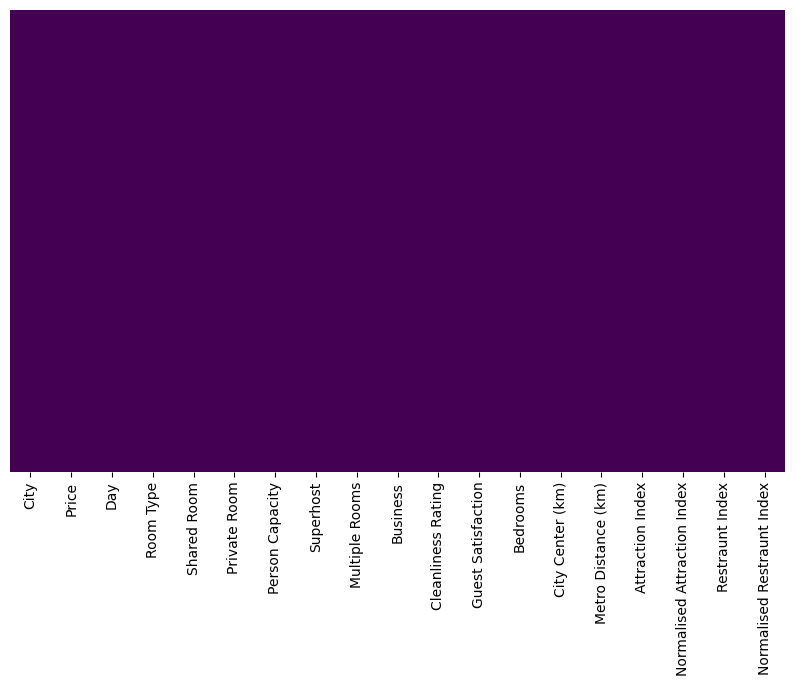

In [144]:
# Fungsi 'sns.heatmap(data_airbnb.isnull())' digunakan untuk membuat heatmap yang menggambarkan pola data yang hilang
# (missing values) dalam DataFrame. 

plt.figure (figsize=(10,6))
sns.heatmap(data.isnull(), yticklabels = False, cmap = 'viridis' , cbar = False)

Berdasarkan hasil pengecekan missing value, tidak ditemukan data kosong (missing value) pada seluruh variabel dalam dataset Airbnb. Hal ini menunjukkan bahwa dataset memiliki kualitas data yang baik karena setiap observasi terisi lengkap tanpa adanya nilai yang hilang. Dengan demikian, proses analisis dan pemodelan dapat dilakukan secara langsung tanpa memerlukan tahap penanganan missing value seperti imputasi data maupun penghapusan observasi. Selain itu, kelengkapan data ini dapat membantu meningkatkan keakuratan hasil analisis dan model yang dibangun.

### Distribusi Data

<AxesSubplot:xlabel='Guest Satisfaction', ylabel='Count'>

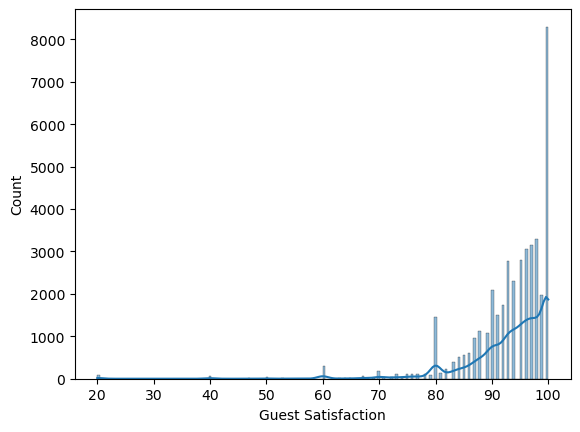

In [145]:
sns.histplot(data_airbnb['Guest Satisfaction'], kde=True)

<AxesSubplot:xlabel='Price', ylabel='Count'>

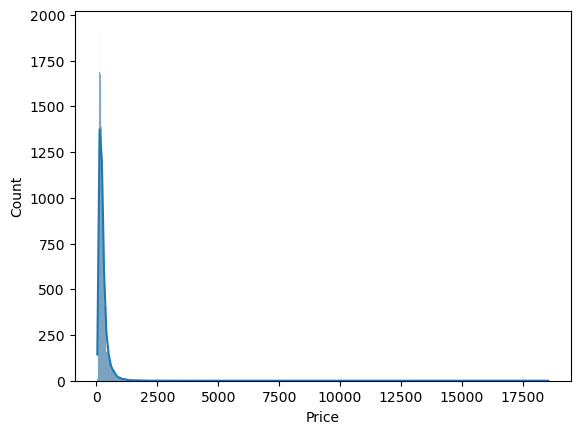

In [146]:
sns.histplot(data_airbnb['Price'], kde=True)

<AxesSubplot:xlabel='Cleanliness Rating', ylabel='Count'>

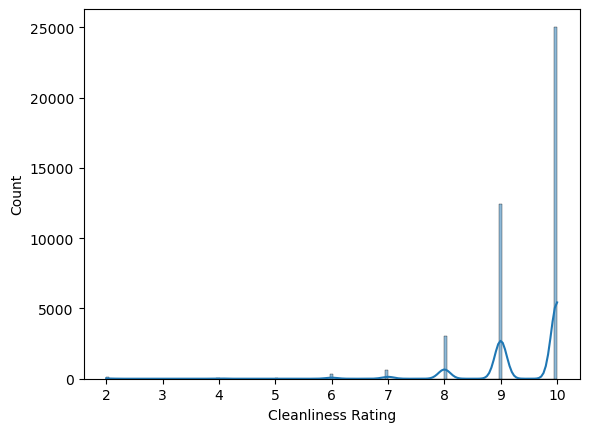

In [147]:
sns.histplot(data_airbnb['Cleanliness Rating'], kde=True)

<AxesSubplot:xlabel='City Center (km)', ylabel='Count'>

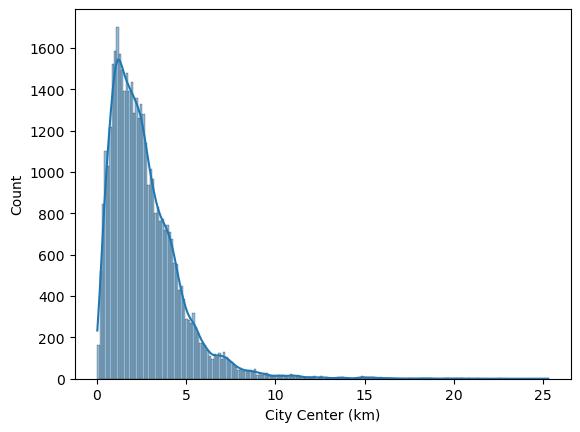

In [148]:
sns.histplot(data_airbnb['City Center (km)'], kde=True)

<AxesSubplot:xlabel='Metro Distance (km)', ylabel='Count'>

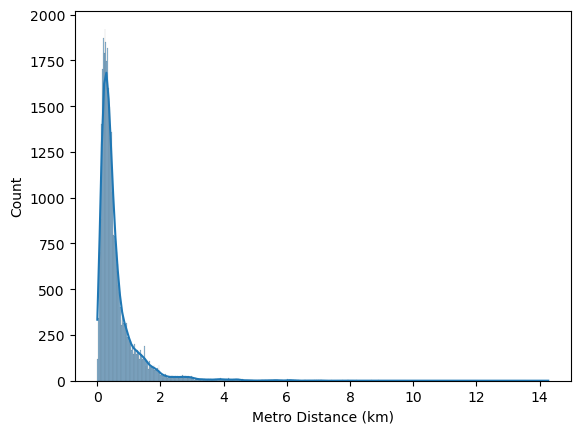

In [149]:
sns.histplot(data_airbnb['Metro Distance (km)'], kde=True)

<AxesSubplot:xlabel='Bedrooms', ylabel='Count'>

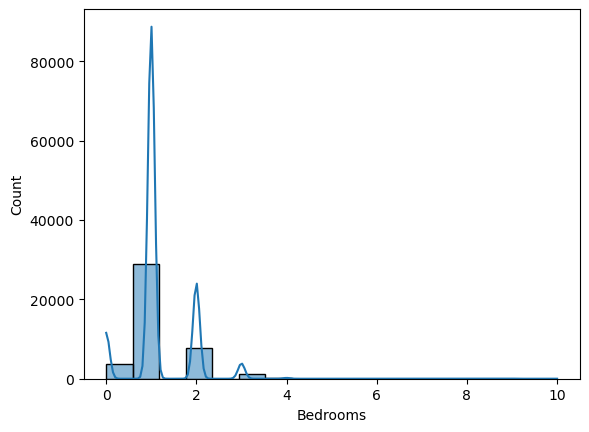

In [150]:
sns.histplot(data_airbnb['Bedrooms'], kde=True)

### Korelasi

Tabel korelasi digunakan untuk menunjukkan hubungan antardata dataframe. Pada tabel korelasi data airbnb berikut, akan dilihat korelasi antara data target ('Guest Satisfaction') dengan variabel-variabel data lainnya. Akan dilihat korelasi masing-masing data dari rentang -1 sampai 1.

In [151]:
# Fungsi 'corr()' digunakan pada objek DataFrame untuk menghitung matriks korelasi antara kolom-kolom dalam DataFrame. 
# Fungsi 'style.background_gradient()' digunakan untuk menerapkan pewarnaan latar belakang pada DataFrame, 
# sehingga memvisualisasikan koefisien korelasi dengan gradasi warna. 
# Fungsi 'set_precision()' digunakan untuk mengatur presisi atau jumlah angka desimal yang ditampilkan dalam DataFrame.

data.corr().style.background_gradient().set_precision(2)

,Price,Shared Room,Private Room,Person Capacity,Superhost,Multiple Rooms,Business,Cleanliness Rating,Guest Satisfaction,Bedrooms,City Center (km),Metro Distance (km),Attraction Index,Normalised Attraction Index,Restraunt Index,Normalised Restraunt Index
Price,1.00,-0.04,-0.15,0.18,-0.04,-0.06,0.01,0.00,0.02,0.21,-0.05,-0.04,0.17,0.27,0.11,0.22
Shared Room,-0.04,1.00,-0.06,0.04,-0.03,-0.02,0.06,-0.05,-0.04,-0.02,0.02,-0.02,-0.03,0.00,-0.03,0.00
Private Room,-0.15,-0.06,1.00,-0.48,-0.06,0.15,-0.02,-0.03,-0.05,-0.14,0.13,0.03,0.00,-0.00,0.01,-0.07
Person Capacity,0.18,0.04,-0.48,1.00,0.04,-0.06,0.10,0.01,0.02,0.56,-0.08,0.01,0.01,-0.05,0.02,-0.01
Superhost,-0.04,-0.03,-0.06,0.04,1.00,0.09,-0.09,0.28,0.29,0.02,-0.02,0.01,-0.02,-0.06,-0.03,-0.06
Multiple Rooms,-0.06,-0.02,0.15,-0.06,0.09,1.00,-0.47,0.03,0.04,-0.01,0.03,0.04,0.02,-0.02,0.02,-0.04
Business,0.01,0.06,-0.02,0.10,-0.09,-0.47,1.00,-0.08,-0.18,-0.02,-0.18,-0.07,0.09,0.02,0.11,0.09
Cleanliness Rating,0.00,-0.05,-0.03,0.01,0.28,0.03,-0.08,1.00,0.69,0.03,0.00,0.02,-0.02,-0.04,-0.03,-0.05
Guest Satisfaction,0.02,-0.04,-0.05,0.02,0.29,0.04,-0.18,0.69,1.00,0.04,0.03,0.03,-0.05,-0.02,-0.07,-0.05
Bedrooms,0.21,-0.02,-0.14,0.56,0.02,-0.01,-0.02,0.03,0.04,1.00,0.00,0.05,-0.02,-0.08,-0.02,-0.08


Berdasarkan hasil analisis korelasi, variabel yang memiliki hubungan paling kuat dengan Guest Satisfaction adalah Cleanliness Rating dengan nilai korelasi sebesar 0,69. Selain itu, variabel Superhost dan Business juga menunjukkan hubungan terhadap kepuasan tamu meskipun dengan tingkat korelasi yang lebih rendah. Oleh karena itu, variabel-variabel tersebut dipertimbangkan sebagai fitur yang relevan dalam proses pemodelan prediksi kepuasan tamu Airbnb.

Variabel lainnya seperti Price, Person Capacity, Bedrooms, City Center (km), dan Metro Distance (km) memiliki nilai korelasi yang relatif kecil terhadap Guest Satisfaction, sehingga hubungan linear yang dimiliki tergolong lemah. Namun demikian, variabel-variabel tersebut masih dapat digunakan dalam pemodelan karena kemungkinan tetap memberikan kontribusi terhadap prediksi ketika dikombinasikan dengan variabel lainnya. Secara umum, hasil korelasi menunjukkan bahwa faktor kebersihan merupakan aspek yang paling berpengaruh terhadap kepuasan tamu Airbnb dalam dataset ini.

## Menentukan Target dan Prediktor

Berdasarkan analisis sebelumnya, target dan prediktor yang ditentukan yaitu
Target (Y) = Guest Satisfaction
Prediktor (X) = Cleanliness Rating, Superhost, Bussiness, Price, Person Capacity

## Training Model

In [152]:
X = data[['Cleanliness Rating','Bedrooms','Restraunt Index','Business','Superhost','Private Room']]

y = data['Guest Satisfaction']

Karena Guest Satisfaction berupa data numerik, maka lebih tepat menggunakan Linear Regression

## Membagi Data Training dan Testing

Dataset dibagi menjadi data training dan data testing dengan proporsi 80:20. Sebanyak 80% data digunakan untuk melatih model, sedangkan 20% sisanya digunakan untuk menguji performa model terhadap data yang belum pernah dipelajari sebelumnya. Pembagian ini dilakukan agar model dapat dievaluasi secara lebih objektif dan mengurangi risiko overfitting.

In [153]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Scaling Data

Scalling Data dilakukan karena terdapat perbedaan skala pada prediktor seperti price dan cleanliness rating. 

In [154]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Membuat Model Linear Regression

In [155]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

## Training Model

In [156]:
model.fit(X_train, y_train)

LinearRegression()

Model dilatih untuk mempelajari hubungan antara fitur Airbnb dengan tingkat kepuasan tamu

## Hasil Prediksi Data Testing

In [157]:
y_pred = model.predict(X_test)

## Evaluasi Model 

In [158]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R^2  :", r2)

MAE : 3.711527119900607
RMSE: 5.702831850556911
R^2  : 0.5240576064510947


## Melihat Pengaruh Variabel

In [159]:
coef = pd.DataFrame({
    'Prediktor': X.columns,
    'Koefisien': model.coef_
})

print(coef)

            Prediktor  Koefisien
0  Cleanliness Rating   5.278120
1            Bedrooms   0.111789
2     Restraunt Index  -0.296615
3            Business  -0.924328
4           Superhost   0.778451
5        Private Room  -0.233280


Berdasarkan hasil koefisien regresi, setiap variabel memiliki pengaruh yang berbeda terhadap Guest Satisfaction. Variabel Cleanliness Rating memiliki koefisien positif terbesar yaitu sebesar 5,278, yang menunjukkan bahwa tingkat kebersihan merupakan faktor yang paling berpengaruh dalam meningkatkan kepuasan tamu. Artinya, setiap peningkatan nilai kebersihan cenderung meningkatkan nilai Guest Satisfaction. Variabel Superhost juga memiliki pengaruh positif dengan koefisien sebesar 0,778, sehingga penginapan dengan status superhost cenderung memperoleh tingkat kepuasan tamu yang lebih tinggi. Selain itu, variabel Bedrooms memiliki pengaruh positif yang sangat kecil sebesar 0,112, yang mengindikasikan bahwa jumlah kamar tidur hanya sedikit memengaruhi kepuasan tamu.

Sementara itu, variabel Business, Restraunt Index, dan Private Room memiliki koefisien negatif terhadap Guest Satisfaction. Variabel Business memiliki pengaruh negatif terbesar dengan koefisien sebesar -0,924, yang menunjukkan bahwa listing bertipe bisnis cenderung memiliki tingkat kepuasan tamu yang lebih rendah dibandingkan non-bisnis. Variabel Restraunt Index dan Private Room juga menunjukkan hubungan negatif, meskipun pengaruhnya relatif kecil. Secara umum, hasil model menunjukkan bahwa faktor kebersihan menjadi aspek utama yang memengaruhi tingkat kepuasan tamu Airbnb dibandingkan variabel lainnya.

## Kesimpulan

Berdasarkan hasil analisis dan pemodelan yang telah dilakukan, dapat disimpulkan bahwa fitur layanan dan karakteristik penginapan Airbnb memiliki pengaruh terhadap tingkat Guest Satisfaction. Variabel yang paling berpengaruh dalam meningkatkan kepuasan tamu adalah Cleanliness Rating, yang menunjukkan bahwa tingkat kebersihan penginapan menjadi faktor utama dalam menentukan pengalaman pelanggan. Selain itu, status Superhost juga memberikan pengaruh positif terhadap kepuasan tamu, sedangkan variabel Business, Restraunt Index, dan Private Room cenderung memberikan pengaruh negatif terhadap tingkat kepuasan pelanggan.

Hasil evaluasi model menunjukkan nilai MAE sebesar 3,71 dan RMSE sebesar 5,70, yang menandakan bahwa rata-rata kesalahan prediksi model masih berada dalam rentang yang cukup baik. Selain itu, nilai R² sebesar 0,524 menunjukkan bahwa model mampu menjelaskan sekitar 52,4% variasi pada variabel Guest Satisfaction, sementara sisanya dipengaruhi oleh faktor lain di luar model. Secara umum, model yang dibangun memiliki performa yang cukup baik dalam memprediksi tingkat kepuasan tamu Airbnb berdasarkan fitur layanan yang digunakan. Oleh karena itu, peningkatan kualitas kebersihan, pelayanan host, dan kenyamanan penginapan dapat menjadi faktor penting untuk meningkatkan kepuasan pelanggan Airbnb.